# RAPID-MFA-10: Material substitution

## Descriptions
This module implements material substitution gradually over time. This is illustrated with the example of cars. Rather than a sudden change from one year to the next, like in `RAPID-MFA-10a: Immediate material substitution`, the new material intensities are now only reached after 10 years of transition time. In this example we assume a linear change, but this can, and should, be freely modified and fit to your specific case. Note that in this example the car type stays the same, but its material composition changes, while in `RAPID-MFA-11: Type substitution` the material composition of each car type is stable, but the share of car types in the inflow changes.

A new alloy is gradually introduced to the market. In 2025, 1% of new cars have the new MIs, growing linearly to 50% of new cars sold in 2050. The rest have the original MIs. For clarity and simplicity we treat the cars with the old MIs and those with new MIs as two separate products, each with their own flow-driven dynamic MFA that will get converted to steel and aluminum with their appropriate MIs. For that we split the total inflows of vehicles into the two separate types. Then we can calculate two separate dMFAs that together represent the complete system.

# If the change happens in just one year, switch once and keep the new value
# transition_series.loc[transition_timeframe_start:] = material_intensities_dict["substitution"]

# NOTE for __Tomer__:
If you have time, you thought about adding the system figure like in RAPID-MFA-9, but here visualizing the two material layers.

### Relations with other RAPID-MFA codes
- This model builds on the basic `RAPID-MFA-2: The stock driven model`, which is used as the core building block for all other RAPID-MFA codes that use the stock driven model.
- `RAPID-MFA-5: Different lifetime functions`: The code below uses the Weibull lifetime distribution as introduced in module 5. The shape and scale parameters were adapted to the literature source.
- `RAPID-MFA-5: Type substitution`: In this module the car types stay the same but their MI changes, in the type substitution module the car type, which has a different MI, is changed. While they are not the same they can be related, so check which one fits your specific case.

### Relations with other RAPID-MFA codes
- This model builds on `RAPID-MFA-9: Switching from products/services to materials with changing material composition`, which is used as the core building block.
- `RAPID-MFA-5: Different lifetime functions`: The code below uses the Weibull lifetime distribution as introduced in module 5. The shape and scale parameters were adapted to the literature source.
- `RAPID-MFA-11: Type substitution`: In this module the car types stay the same but their MI changes, in the type substitution module the car type, which has a different MI, is changed. While they are not the same they can be related, so verify which one fits your specific case.

### Data sources
__Stocks:__ From https://doi.org/10.3390/resources7010009

__Survival curve:__ Weibull distribution, $shape=2.4$, $scale=16.9$, e.g. using `scipy.stats.weibull_min.sf(range(0, len(input_data)), c = 2.428914875, loc = 0, scale = 16.93851375)` Data from https://doi.org/10.3390/resources7010009

__Material intensity:__ In kg/vehicle from Fishman, T., Myers, R.J., Rios, O., Graedel, T.E., 2018. Implications of Emerging Vehicle Technologies on Rare Earth Supply and Demand in the United States.
 Resources 7 (https://doi.org/10.3390/resources7010009)

### Version, licence, and how to cite

Version 2026.7 - check the [RAPID MFA GitHub repository](https://github.com/TomerFishman/RAPID-MFA/) for changes, history, and updates.

This code was created and is maintained by the [RAPID MFA development team](https://github.com/TomerFishman/RAPID-MFA/tree/master#contributors-and-acknowledgements).

This notebook is <a href="https://creativecommons.org/licenses/by-nc/4.0"><img src="https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc.png" alt="CC-BY-NC" width="70"> CC-BY-NC</a>, meaning you can - and should! - freely reuse and adapt this code for noncommercial purposes __as long as you attribute this source__.

## 1. Load libraries

In [1]:
# %% 1. Load libraries
import numpy as np
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Define example input data

In [2]:
# %% 2. Define example input data
input_data = pd.Series([0, 17, 9367, 29639, 65611, 112994, 196655, 405237, 655629, 1002834, 1307203,
                        1584131, 1836332, 2092277, 2537144, 3074043, 3567853, 4207156, 4945879, 5797925,
                        6778277, 7902746, 9187646, 10649295, 12303394, 14164318, 16244276, 18552466,
                        21094228, 23870337, 26876417, 30102657, 33533764, 37149274, 40924083, 44829315, 48833234,
                        52902345, 57002464, 61099726, 65161509, 69157195, 73058775, 76841335, 80483330, 83966772,
                        87277263, 90403948, 93339367, 96079253, 98622261, 100969690, 103125124],
                       name = 'stocks', 
                       index = [1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008,
                                2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
                                2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030,
                                2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041,
                                2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050])

# Define the transition start year and the transition end year
transition_timeframe_start = 2025
transition_timeframe_end = 2035

# Define the materials
materials = ["aluminium", "steel"]

# Define the material intensities in g/vehicle
material_intensities_dict = {
    materials[0]: [114.51, 154.07340],
    materials[1]: [1056.21065, 911.80425],
}

# Parameters for the survival curve
ages = range(0, len(input_data))
shape = 2.428914875
scale = 16.93851375

### 2.1 Survival curve

In [3]:
survival_curve = scipy.stats.weibull_min.sf(ages, shape, 0, scale)

### 2.2. Material intensities

<Axes: xlabel='Year', ylabel='kg/vehicle'>

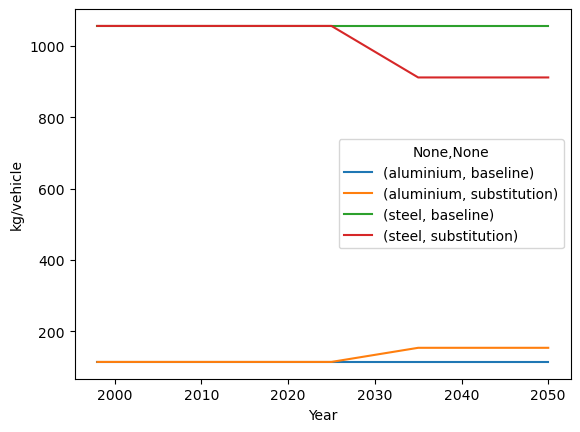

In [6]:
# Create a dataframe for the material intensity data
material_intensities = pd.DataFrame(
    index=input_data.index,
    columns=pd.MultiIndex.from_product([materials, ["baseline", "substitution"]]),
    dtype=float,
)

for material, values in material_intensities_dict.items():
    # Baseline value stays constant before the transition starts
    material_intensities[(material, "baseline")] = values[0]

    # Create a time series for the substitution value
    transition_series = pd.Series(values[0], index=input_data.index, dtype=float)

    # Before the transition starts, the baseline intensity applies
    transition_series.loc[: transition_timeframe_start - 1] = values[0]
    # If the transition spans multiple years, interpolate gradually
    if transition_timeframe_end > transition_timeframe_start:
        transition_series.loc[transition_timeframe_start:transition_timeframe_end] = np.interp(
            np.arange(transition_timeframe_start, transition_timeframe_end + 1),
            [transition_timeframe_start, transition_timeframe_end],
            [values[0], values[1]],
        )

        # After the transition period, the substitution intensity applies
        transition_series.loc[transition_timeframe_end + 1 :] = values[1]

    # If the change happens in just one year, switch once and keep the new value
    else:
        transition_series.loc[transition_timeframe_start:] = values[1]

    # Store the resulting series in the dataframe
    material_intensities[(material, "substitution")] = transition_series

material_intensities.plot(ylabel="kg/vehicle", xlabel="Year")

## 3. Run the MFA system

The steps from hereon are a repetition of notebook 9, but with different input data. If you want a more detailed account on how to do this, see notebook 9.

In [9]:
# %% 3. Run the stock-driven model
# %%% 3.1 Set up the MFA system
units = {'time_interval':   'year', 
         'flows_products':  'vehicles/year', 
         'stocks_products': 'vehicles', 
         'flows_materials': 'grams/year', 
         'stocks_materials':'grams'}

timeframes = cohorts = input_data.index  # timeframes are the "snapshots" of the system in every time interval, while cohorts are the inflows that enter the system in every time interval. They are the same because we have one inflow per time interval.
time_interval = 1
cohort_stop = (cohorts[-1] + time_interval)  # because of exclusive slicing in python, an extra time interval is required
mfa_system_baseline_vehicles = pd.DataFrame(index = timeframes, columns = ['stocks',
                                                                            'inflows', 
                                                                            'outflows',
                                                                            'stock_changes'])

mfa_system_baseline_vehicles['stocks'] = input_data

# %%% 3.2 Create survival curves matrix
# create survival curves matrix filled with zeros
survival_curve_matrix_baseline = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# and populate that matrix
for cohort in cohorts:
    # at each iteration, shift the survival curve and fill the next column of the survival curves matrix with the shifted survival curve from the diagonal downwards.
    survival_curve_matrix_baseline.loc[cohort: , cohort] = survival_curve[0 : cohort_stop - cohort]
   
# %%% 3.3 Create cohorts survival matrix
# initialize the cohort_survival_matrix filled with zeros
cohorts_survival_matrix_baseline = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# And populate it
for cohort in cohorts:
    # calculate the inflow of the time-th year
    mfa_system_baseline_vehicles.loc[cohort, 'inflows'] = (
        mfa_system_baseline_vehicles.loc[cohort, 'stocks'] - cohorts_survival_matrix_baseline.loc[cohort, : cohort - 1].sum()
    ) / survival_curve_matrix_baseline.loc[cohort, cohort]
    # now that the time-th inflow is known, scale the shifted survival curve with this inflow
    cohorts_survival_matrix_baseline.loc[:, cohort] = survival_curve_matrix_baseline.loc[:, cohort] * mfa_system_baseline_vehicles.loc[cohort, 'inflows']
    
# %%% 3.4 Calculate the MFA system
mfa_system_baseline_vehicles["stock_changes"] = np.diff(mfa_system_baseline_vehicles["stocks"], prepend=0)
mfa_system_baseline_vehicles["outflows"] = mfa_system_baseline_vehicles["inflows"] - mfa_system_baseline_vehicles["stock_changes"]

In [11]:
# then convert from the product layer to the material layer using inflow-driven dMFA
mfa_system_baseline_materials = pd.DataFrame(
    index=timeframes,
    columns=pd.MultiIndex.from_product(
        [materials, mfa_system_baseline_vehicles.columns],
        names=['material', 'timeseries']
    )
)

for material in materials:
    baseline_value = material_intensities.loc[material, "baseline"]
    mfa_system_baseline_materials[(material, 'inflows')] = (
        mfa_system_baseline_vehicles['inflows'] * baseline_value
    )

    cohorts_survival_matrix_materials = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)
    for cohort in cohorts:
        cohorts_survival_matrix_materials.loc[:, cohort] = (
            survival_curve_matrix_baseline.loc[:, cohort]
            * mfa_system_baseline_materials[(material, 'inflows')].loc[cohort]
        )

    mfa_system_baseline_materials[(material, 'stocks')] = cohorts_survival_matrix_materials.sum(axis='columns')
    mfa_system_baseline_materials[(material, 'stock_changes')] = np.diff(
        mfa_system_baseline_materials[(material, 'stocks')], prepend=0
    )
    mfa_system_baseline_materials[(material, 'outflows')] = (
        mfa_system_baseline_materials[(material, 'inflows')]
        - mfa_system_baseline_materials[(material, 'stock_changes')]
    )

## 4. Calculate the substitution of material

In [14]:
mfa_system_substitution_materials = pd.DataFrame(
    index=timeframes,
    columns=pd.MultiIndex.from_product(
        [materials, mfa_system_baseline_vehicles.columns],
        names=['material', 'timeseries']
    )
)

for material in materials:
    substitution_value = material_intensities.loc[material, "substitution"]
    mfa_system_substitution_materials[(material, 'inflows')] = (
        mfa_system_baseline_vehicles['inflows'] * substitution_value
    )

    cohorts_survival_matrix_materials = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)
    for cohort in cohorts:
        cohorts_survival_matrix_materials.loc[:, cohort] = (
            survival_curve_matrix_baseline.loc[:, cohort]
            * mfa_system_substitution_materials[(material, 'inflows')].loc[cohort]
        )

    mfa_system_substitution_materials[(material, 'stocks')] = cohorts_survival_matrix_materials.sum(axis='columns')
    mfa_system_substitution_materials[(material, 'stock_changes')] = np.diff(
        mfa_system_substitution_materials[(material, 'stocks')], prepend=0
    )
    mfa_system_substitution_materials[(material, 'outflows')] = (
        mfa_system_substitution_materials[(material, 'inflows')]
        - mfa_system_substitution_materials[(material, 'stock_changes')]
    )

## 6. Compare MFA results

<Axes: title={'center': 'Substitution'}, ylabel='grams/year'>

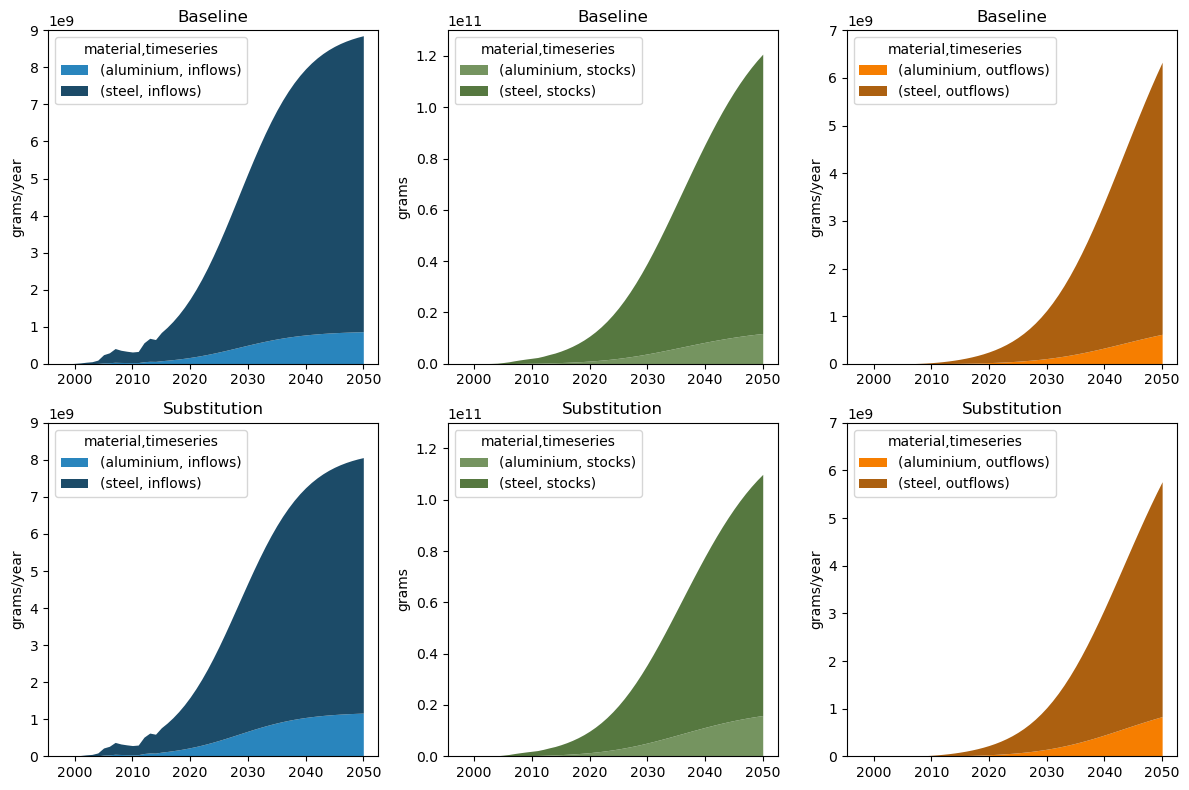

In [13]:
# visualize the inflows, outflows, and stocks results for the baseline and scenario B
results_fig, results_ax = plt.subplots(nrows=2, ncols=3, figsize=(12, 8), tight_layout=True)
# plotting the baseline results
mfa_system_baseline_materials.loc[:, (slice(None), 'inflows')].plot(ylabel=units['flows_materials'], 
                                                                                   kind='area', ylim=(0, 9e9),
                                                                                   color=["#2985BD", "#1C4B68", "#62B5E9", "#517388"],
                                                                                   ax=results_ax[0, 0],
                                                                                   linewidth = 0,
                                                                                   title = 'Baseline'
                                                                                   )
mfa_system_baseline_materials.loc[:, (slice(None), 'stocks')].plot(ylabel=units['stocks_materials'], 
                                                                                  kind='area', ylim=(0, 1.3e11),
                                                                                  color=["#759460", "#567840", "#A9D18E", "#7B9740"],
                                                                                  ax=results_ax[0, 1],
                                                                                  linewidth = 0,
                                                                                  title = 'Baseline'
                                                                                  )
mfa_system_baseline_materials.loc[:, (slice(None), 'outflows')].plot(ylabel=units['flows_materials'], 
                                                                                    kind='area', ylim=(0, 7e9),
                                                                                    color=["#F67E00", "#AC6010", "#F9A16B", "#B06A2E"],
                                                                                    ax=results_ax[0, 2],
                                                                                    linewidth = 0,
                                                                                    title = 'Baseline'
                                                                                    )
# plotting the scenario B results
mfa_system_substitution_materials.loc[:, (slice(None), 'inflows')].plot(ylabel=units['flows_materials'], 
                                                                                   kind='area', ylim=(0, 9e9),
                                                                                   color=["#2985BD", "#1C4B68", "#62B5E9", "#517388"],
                                                                                   ax=results_ax[1, 0],
                                                                                   linewidth = 0,
                                                                                   title = 'Substitution'
                                                                                   )
mfa_system_substitution_materials.loc[:, (slice(None), 'stocks')].plot(ylabel=units['stocks_materials'], 
                                                                                  kind='area', ylim=(0, 1.3e11),
                                                                                  color=["#759460", "#567840", "#A9D18E", "#7B9740"],
                                                                                  ax=results_ax[1, 1],
                                                                                  linewidth = 0,
                                                                                  title = 'Substitution'
                                                                                  )
mfa_system_substitution_materials.loc[:, (slice(None), 'outflows')].plot(ylabel=units['flows_materials'], 
                                                                                    kind='area', ylim=(0, 7e9),
                                                                                    color=["#F67E00", "#AC6010", "#F9A16B", "#B06A2E"],
                                                                                    ax=results_ax[1, 2],
                                                                                    linewidth = 0,
                                                                                    title = 'Substitution'
                                                                                    )



### Material stock productivity

$\text{Material stock productivity} = \frac{\text{service provision}}{\text{material stock}}$

Text(0.5, 0, 'year')

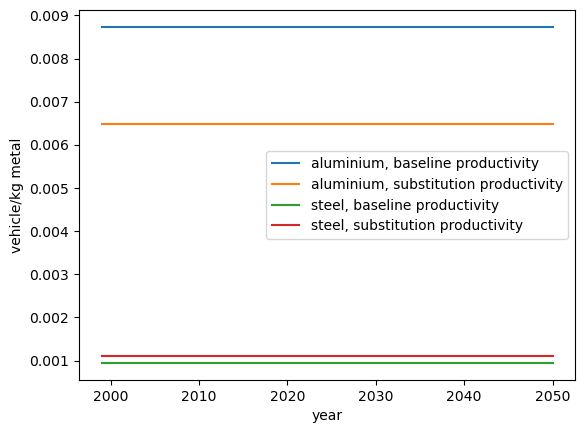

In [15]:
for material in materials:
    baseline_productivity = mfa_system_baseline_vehicles['stocks'] / mfa_system_baseline_materials[(material, 'stocks')]
    substitution_productivity = mfa_system_baseline_vehicles['stocks'] / mfa_system_substitution_materials[(material, 'stocks')]
    baseline_productivity.plot(label=f'{material}, baseline productivity')
    substitution_productivity.plot(label=f'{material}, substitution productivity')

plt.legend()
plt.ylabel('vehicle/kg metal')
plt.xlabel('year')